# 01 - Preprocessing & EDA

**Dataset:** CICIoT2023
**Goal:** Load, clean, explore, and save in a ready-to-use format.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler, LabelEncoder
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

DATA = Path('D:/S2/thesis/Conda/CICIOT23')
OUT = Path('D:/Project/riset/fl-gnn/dataset-clean')
OUT.mkdir(exist_ok=True)
print('Libraries ready.')

Libraries ready.


In [2]:
TRAIN_CSV = DATA / 'train' / 'train.csv'
VAL_CSV = DATA / 'validation' / 'validation.csv'
TEST_CSV = DATA / 'test' / 'test.csv'

# Memory optimization: sample first for optimal dtypes
print('Scanning schema...')
dtypes_samp = pd.read_csv(TRAIN_CSV, nrows=1000, low_memory=False).dtypes
float_cols = dtypes_samp[dtypes_samp == 'float64'].index.tolist()
int_cols = dtypes_samp[dtypes_samp == 'int64'].index.tolist()

dtype_dict = {c: 'float32' for c in float_cols}
dtype_dict.update({c: 'int32' for c in int_cols})
print(f'float64->float32: {len(float_cols)} cols, int64->int32: {len(int_cols)} cols')

# Load with low_memory=True + optimized dtype
print('Loading train.csv...')
train = pd.read_csv(TRAIN_CSV, low_memory=True, dtype=dtype_dict)
print(f'Train: {train.shape}')
print('Loading validation.csv...')
val = pd.read_csv(VAL_CSV, low_memory=True, dtype=dtype_dict)
print(f'Val:   {val.shape}')
print('Loading test.csv...')
test = pd.read_csv(TEST_CSV, low_memory=True, dtype=dtype_dict)
print(f'Test:  {test.shape}')

mem_mb = (train.memory_usage(deep=True).sum() / 1024 / 1024)
print(f'Memory train: {mem_mb:.0f} MB')

Scanning schema...
float64->float32: 46 cols, int64->int32: 0 cols
Loading train.csv...
Train: (5491971, 47)
Loading validation.csv...
Val:   (1176851, 47)
Loading test.csv...
Test:  (1176851, 47)
Memory train: 1343 MB


## 1. Exploratory Data Analysis

In [3]:
print('Columns:')
for i, c in enumerate(train.columns):
    print(f'  {i:2d}. {c}')

print(f'\nUnique classes: {train["label"].nunique()}')

Columns:
   0. flow_duration
   1. Header_Length
   2. Protocol Type
   3. Duration
   4. Rate
   5. Srate
   6. Drate
   7. fin_flag_number
   8. syn_flag_number
   9. rst_flag_number
  10. psh_flag_number
  11. ack_flag_number
  12. ece_flag_number
  13. cwr_flag_number
  14. ack_count
  15. syn_count
  16. fin_count
  17. urg_count
  18. rst_count
  19. HTTP
  20. HTTPS
  21. DNS
  22. Telnet
  23. SMTP
  24. SSH
  25. IRC
  26. TCP
  27. UDP
  28. DHCP
  29. ARP
  30. ICMP
  31. IPv
  32. LLC
  33. Tot sum
  34. Min
  35. Max
  36. AVG
  37. Std
  38. Tot size
  39. IAT
  40. Number
  41. Magnitue
  42. Radius
  43. Covariance
  44. Variance
  45. Weight
  46. label

Unique classes: 34


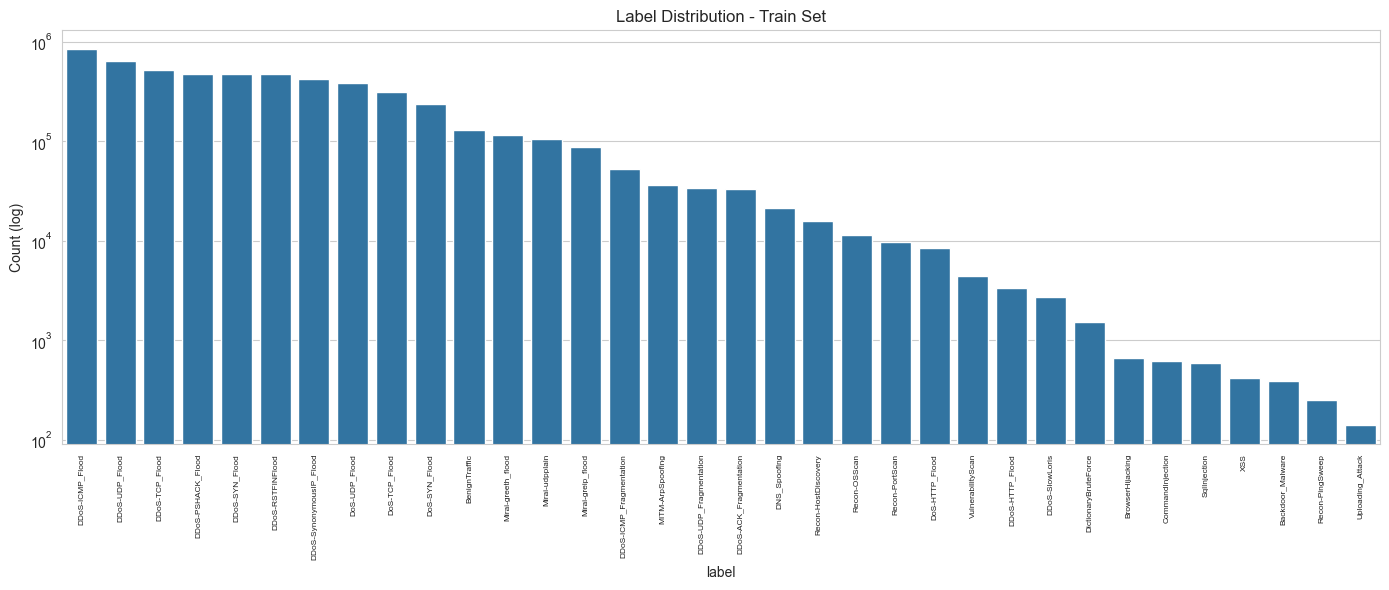

In [4]:
plt.figure(figsize=(14, 6))
label_counts = train['label'].value_counts()
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.xticks(rotation=90, fontsize=6)
plt.yscale('log')
plt.ylabel('Count (log)')
plt.title('Label Distribution - Train Set')
plt.tight_layout()
plt.show()

## 2. Preprocessing

In [5]:
label_col = 'label'

# Drop ID columns and constant columns
id_cols = [c for c in train.columns if 'id' in c.lower()]
constant_cols = [c for c in train.columns if c != label_col and train[c].nunique() <= 1]
drop_cols = list(set(id_cols + constant_cols))

train = train.drop(columns=drop_cols, errors='ignore')
val = val.drop(columns=drop_cols, errors='ignore')
test = test.drop(columns=drop_cols, errors='ignore')
print(f'Dropped {len(drop_cols)} columns: {drop_cols}')

# Numeric columns
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != label_col]
print(f'Feature columns: {len(num_cols)}')

Dropped 2 columns: ['Telnet', 'IRC']
Feature columns: 44


In [6]:
# Handle missing & inf with median
medians = train[num_cols].median()
for df in [train, val, test]:
    df[num_cols] = df[num_cols].fillna(medians)
    df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan).fillna(medians)

# Dedup train
before = len(train)
train = train.drop_duplicates()
print(f'Duplicate train: {before - len(train)} rows removed')

Duplicate train: 1377193 rows removed


In [7]:
# Scaling
scaler = RobustScaler()
X_train = scaler.fit_transform(train[num_cols]).astype('float32')
X_val = scaler.transform(val[num_cols]).astype('float32')
X_test = scaler.transform(test[num_cols]).astype('float32')

# Label encoding
le = LabelEncoder()
y_train = le.fit_transform(train[label_col]).astype('int32')
y_val = le.transform(val[label_col]).astype('int32')
y_test = le.transform(test[label_col]).astype('int32')

print(f'X_train: {X_train.shape} {X_train.dtype}')
print(f'X_val:   {X_val.shape} {X_val.dtype}')
print(f'X_test:  {X_test.shape} {X_test.dtype}')
print(f'Classes: {len(le.classes_)}')

X_train: (4114778, 44) float32
X_val:   (1176851, 44) float32
X_test:  (1176851, 44) float32
Classes: 34


In [8]:
print('Label mapping:')
for i, name in enumerate(le.classes_):
    print(f'  {i:2d} -> {name}')

Label mapping:
   0 -> Backdoor_Malware
   1 -> BenignTraffic
   2 -> BrowserHijacking
   3 -> CommandInjection
   4 -> DDoS-ACK_Fragmentation
   5 -> DDoS-HTTP_Flood
   6 -> DDoS-ICMP_Flood
   7 -> DDoS-ICMP_Fragmentation
   8 -> DDoS-PSHACK_Flood
   9 -> DDoS-RSTFINFlood
  10 -> DDoS-SYN_Flood
  11 -> DDoS-SlowLoris
  12 -> DDoS-SynonymousIP_Flood
  13 -> DDoS-TCP_Flood
  14 -> DDoS-UDP_Flood
  15 -> DDoS-UDP_Fragmentation
  16 -> DNS_Spoofing
  17 -> DictionaryBruteForce
  18 -> DoS-HTTP_Flood
  19 -> DoS-SYN_Flood
  20 -> DoS-TCP_Flood
  21 -> DoS-UDP_Flood
  22 -> MITM-ArpSpoofing
  23 -> Mirai-greeth_flood
  24 -> Mirai-greip_flood
  25 -> Mirai-udpplain
  26 -> Recon-HostDiscovery
  27 -> Recon-OSScan
  28 -> Recon-PingSweep
  29 -> Recon-PortScan
  30 -> SqlInjection
  31 -> Uploading_Attack
  32 -> VulnerabilityScan
  33 -> XSS


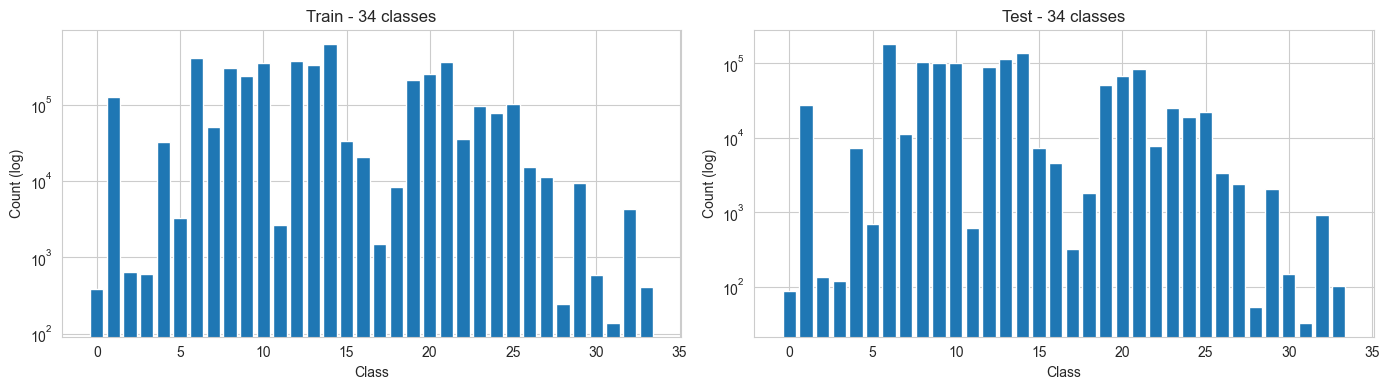

In [9]:
plt.figure(figsize=(14, 4))
plt.subplot(1, 2, 1)
unique, counts = np.unique(y_train, return_counts=True)
plt.bar(unique, counts)
plt.yscale('log')
plt.title(f'Train - {len(unique)} classes')
plt.xlabel('Class')
plt.ylabel('Count (log)')

plt.subplot(1, 2, 2)
unique_t, counts_t = np.unique(y_test, return_counts=True)
plt.bar(unique_t, counts_t)
plt.yscale('log')
plt.title(f'Test - {len(unique_t)} classes')
plt.xlabel('Class')
plt.ylabel('Count (log)')
plt.tight_layout()
plt.show()

## 3. Save (NPZ + Pickle)

**Why NPZ instead of pickle?**  
NPZ compressed is ~2-3x smaller than pickle/joblib, and I/O is much faster.

In [10]:
np.savez_compressed(OUT / 'train.npz', X=X_train, y=y_train)
np.savez_compressed(OUT / 'val.npz', X=X_val, y=y_val)
np.savez_compressed(OUT / 'test.npz', X=X_test, y=y_test)

import joblib
joblib.dump(scaler, OUT / 'scaler.pkl')
joblib.dump(le, OUT / 'label_encoder.pkl')
joblib.dump(num_cols, OUT / 'feature_cols.pkl')

print(f'Saved to {OUT}/')

Saved to D:\Project\riset\fl-gnn\dataset-clean/


In [11]:
print('='*50)
print('SUMMARY')
print('='*50)
print(f'Training samples:   {len(X_train):,}')
print(f'Validation samples: {len(X_val):,}')
print(f'Test samples:       {len(X_test):,}')
print(f'Feature dimensions: {X_train.shape[1]}')
print(f'Attack classes:     {len(le.classes_)}')
print(f'Data type:          {X_train.dtype}')
print('='*50)

SUMMARY
Training samples:   4,114,778
Validation samples: 1,176,851
Test samples:       1,176,851
Feature dimensions: 44
Attack classes:     34
Data type:          float32
